In [57]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/premiugv/coding-platforms-dataset/BestCodingPlatform Dataset.xlsx


In [ ]:
df=pd.read_excel('/kaggle/input/datasets/premiugv/coding-platforms-dataset/BestCodingPlatform Dataset.xlsx')

In [109]:
import sklearn
import joblib
import sys

print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikit-learn: 1.6.1
Joblib: 1.5.3


In [59]:
df['Platform'].value_counts()

Platform
LeetCode      1552
HackerRank    1508
CodeChef      1502
Codeforces    1438
Name: count, dtype: int64

In [60]:
df.shape

(6000, 14)

In [61]:
df.head()

,Platform,Active_Users_M,Avg_Rating,Problems_Count,Problems_Difficulty,Job_Integration,Contest_Frequency,Pricing_Model,Founded_Year,Mobile_App_Available,Certifications_Offered,Learning_Paths,Forum_Activity_Level,Platform_Score
0,HackerRank,5.6,4.2,581,Easy,Yes,Occasionally,Paid,2019,True,True,7,Medium,86
1,HackerRank,28.5,4.4,2256,Hard,Limited,Weekly,Freemium,2013,False,True,5,Low,118
2,Codeforces,17.6,4.4,3773,Varied,No,Weekly,Freemium,2018,True,True,8,Low,102
3,CodeChef,19.9,4.5,2855,Varied,No,Occasionally,Paid,2010,False,False,3,Low,86
4,CodeChef,16.5,4.1,1867,Easy,Yes,Weekly,Free,2021,False,True,3,Low,96


In [62]:
df.to_csv('BestCodingPlatform.csv')

In [63]:
df.shape

(6000, 14)

In [64]:
df.head()

,Platform,Active_Users_M,Avg_Rating,Problems_Count,Problems_Difficulty,Job_Integration,Contest_Frequency,Pricing_Model,Founded_Year,Mobile_App_Available,Certifications_Offered,Learning_Paths,Forum_Activity_Level,Platform_Score
0,HackerRank,5.6,4.2,581,Easy,Yes,Occasionally,Paid,2019,True,True,7,Medium,86
1,HackerRank,28.5,4.4,2256,Hard,Limited,Weekly,Freemium,2013,False,True,5,Low,118
2,Codeforces,17.6,4.4,3773,Varied,No,Weekly,Freemium,2018,True,True,8,Low,102
3,CodeChef,19.9,4.5,2855,Varied,No,Occasionally,Paid,2010,False,False,3,Low,86
4,CodeChef,16.5,4.1,1867,Easy,Yes,Weekly,Free,2021,False,True,3,Low,96


In [65]:
df.describe()

,Active_Users_M,Avg_Rating,Problems_Count,Founded_Year,Learning_Paths,Platform_Score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,15.650767,4.255167,2250.497500,2013.524667,5.490833,93.793333
std,8.329008,0.433603,1005.621145,5.193864,2.875696,15.309736
min,1.000000,3.500000,500.000000,2005.000000,1.000000,48.000000
25%,8.600000,3.900000,1386.750000,2009.000000,3.000000,83.000000
50%,15.700000,4.300000,2254.000000,2014.000000,5.000000,94.000000
75%,22.900000,4.600000,3121.500000,2018.000000,8.000000,105.000000
max,30.000000,5.000000,4000.000000,2022.000000,10.000000,137.000000


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df.isnull().sum()

Platform                  0
Active_Users_M            0
Avg_Rating                0
Problems_Count            0
Problems_Difficulty       0
Job_Integration           0
Contest_Frequency         0
Pricing_Model             0
Founded_Year              0
Mobile_App_Available      0
Certifications_Offered    0
Learning_Paths            0
Forum_Activity_Level      0
Platform_Score            0
dtype: int64

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Platform                6000 non-null   object 
 1   Active_Users_M          6000 non-null   float64
 2   Avg_Rating              6000 non-null   float64
 3   Problems_Count          6000 non-null   int64  
 4   Problems_Difficulty     6000 non-null   object 
 5   Job_Integration         6000 non-null   object 
 6   Contest_Frequency       6000 non-null   object 
 7   Pricing_Model           6000 non-null   object 
 8   Founded_Year            6000 non-null   int64  
 9   Mobile_App_Available    6000 non-null   bool   
 10  Certifications_Offered  6000 non-null   bool   
 11  Learning_Paths          6000 non-null   int64  
 12  Forum_Activity_Level    6000 non-null   object 
 13  Platform_Score          6000 non-null   int64  
dtypes: bool(2), float64(2), int64(4), object

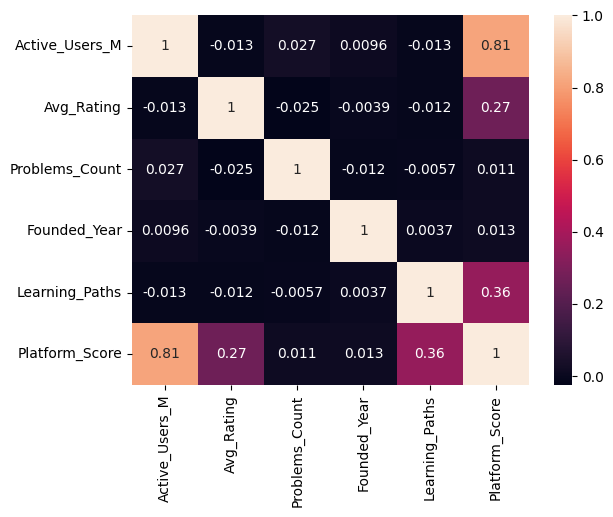

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.select_dtypes("number").corr(), annot=True)
plt.show()

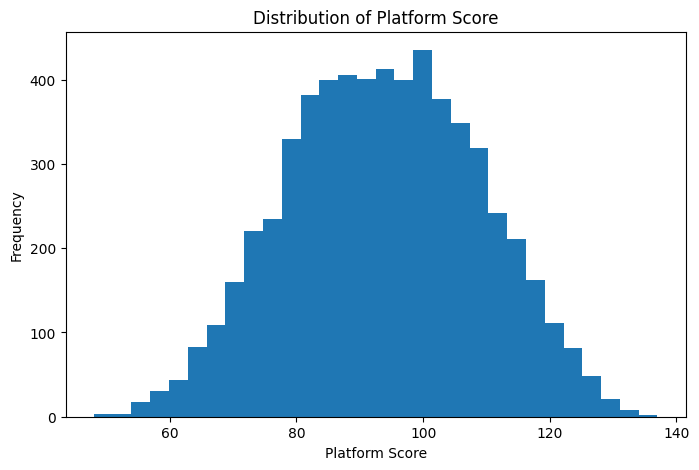

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Platform_Score"], bins=30)
plt.xlabel("Platform Score")
plt.ylabel("Frequency")
plt.title("Distribution of Platform Score")
plt.show()

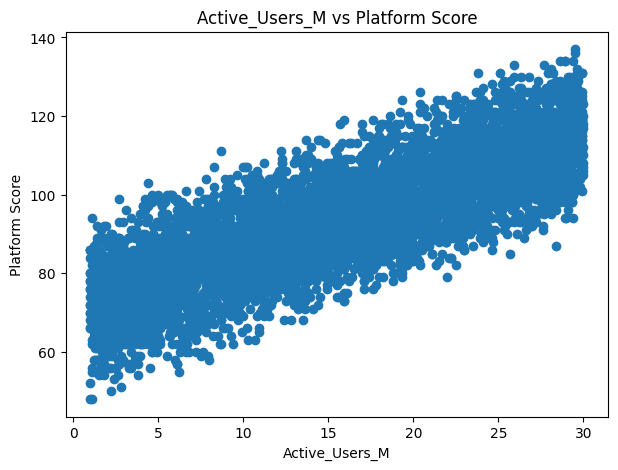

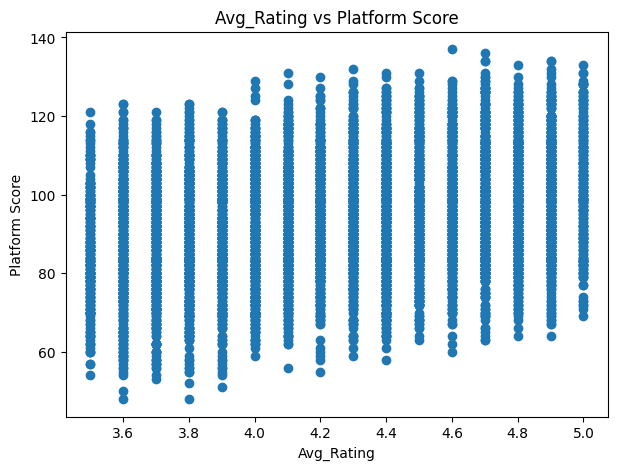

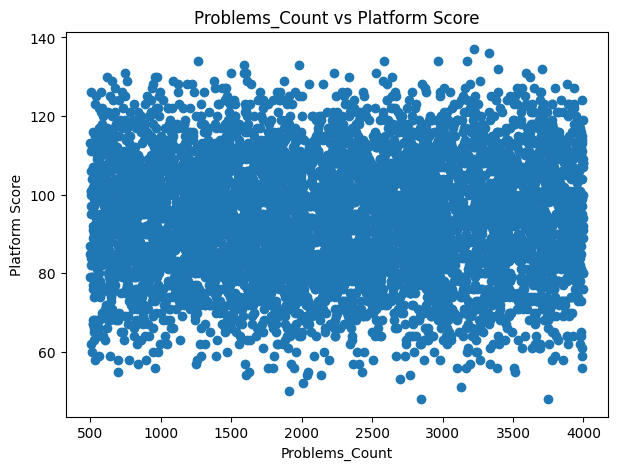

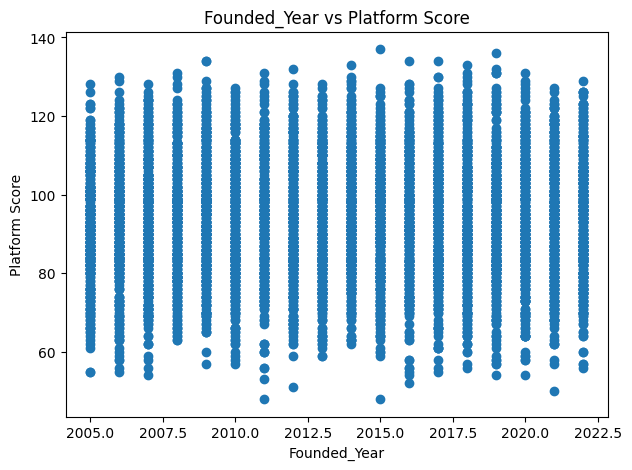

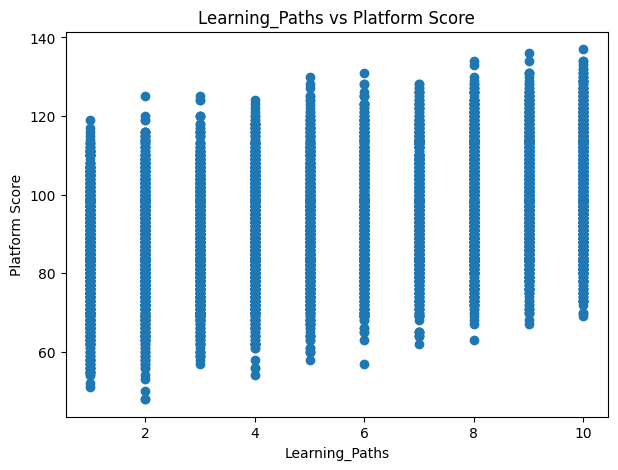

In [71]:
features = [
    "Active_Users_M",
    "Avg_Rating",
    "Problems_Count",
    "Founded_Year",
    "Learning_Paths"
]

for col in features:
    plt.figure(figsize=(7,5))
    plt.scatter(df[col], df["Platform_Score"])
    plt.xlabel(col)
    plt.ylabel("Platform Score")
    plt.title(f"{col} vs Platform Score")
    plt.show()

In [72]:
df[[
    "Active_Users_M",
    "Avg_Rating",
    "Problems_Count",
    "Founded_Year",
    "Learning_Paths",
    "Platform_Score"
]].corr()["Platform_Score"].sort_values(ascending=False)

Platform_Score    1.000000
Active_Users_M    0.813650
Learning_Paths    0.357289
Avg_Rating        0.265957
Founded_Year      0.013267
Problems_Count    0.011242
Name: Platform_Score, dtype: float64

In [73]:
categorical_cols = [
    "Problems_Difficulty",
    "Job_Integration",
    "Contest_Frequency",
    "Pricing_Model",
    "Forum_Activity_Level"
]

for col in categorical_cols:
    print("\n", col)
    print(df.groupby(col)["Platform_Score"].mean().sort_values(ascending=False))


 Problems_Difficulty
Problems_Difficulty
Varied    94.264766
Easy      93.928382
Medium    93.828176
Hard      93.159333
Name: Platform_Score, dtype: float64

 Job_Integration
Job_Integration
Yes        98.951605
Limited    93.792520
No         88.630746
Name: Platform_Score, dtype: float64

 Contest_Frequency
Contest_Frequency
Weekly          96.079215
Monthly         93.310992
Biweekly        93.287326
Occasionally    92.550525
Name: Platform_Score, dtype: float64

 Pricing_Model
Pricing_Model
Freemium    95.351500
Free        93.529624
Paid        92.528412
Name: Platform_Score, dtype: float64

 Forum_Activity_Level
Forum_Activity_Level
High      95.809257
Medium    93.877426
Low       91.804913
Name: Platform_Score, dtype: float64


In [74]:
df.groupby("Platform")["Platform_Score"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
Platform,,,,
CodeChef,93.778961,48,131,1502
Codeforces,94.278164,48,137,1438
HackerRank,93.613395,53,134,1508
LeetCode,93.532861,50,136,1552


In [75]:
df.groupby("Problems_Difficulty")["Platform_Score"].mean().sort_values(ascending=False)

Problems_Difficulty
Varied    94.264766
Easy      93.928382
Medium    93.828176
Hard      93.159333
Name: Platform_Score, dtype: float64

In [76]:
df.groupby("Job_Integration")["Platform_Score"].mean().sort_values(ascending=False)

Job_Integration
Yes        98.951605
Limited    93.792520
No         88.630746
Name: Platform_Score, dtype: float64

In [77]:
df.groupby("Contest_Frequency")["Platform_Score"].mean().sort_values(ascending=False)

Contest_Frequency
Weekly          96.079215
Monthly         93.310992
Biweekly        93.287326
Occasionally    92.550525
Name: Platform_Score, dtype: float64

In [78]:
df.groupby("Pricing_Model")["Platform_Score"].mean().sort_values(ascending=False)

Pricing_Model
Freemium    95.351500
Free        93.529624
Paid        92.528412
Name: Platform_Score, dtype: float64

In [79]:
df.groupby("Forum_Activity_Level")["Platform_Score"].mean().sort_values(ascending=False)

Forum_Activity_Level
High      95.809257
Medium    93.877426
Low       91.804913
Name: Platform_Score, dtype: float64

In [80]:
df.groupby("Platform")["Platform_Score"].agg(
    ["mean", "min", "max", "count"]
).sort_values("mean", ascending=False)

,mean,min,max,count
Platform,,,,
Codeforces,94.278164,48,137,1438
CodeChef,93.778961,48,131,1502
HackerRank,93.613395,53,134,1508
LeetCode,93.532861,50,136,1552


In [81]:
df["Mobile_App_Available"] = df["Mobile_App_Available"].astype(int)
df["Certifications_Offered"] = df["Certifications_Offered"].astype(int)

# Feature Engineering

In [82]:
df["Mobile_App_Available"] = df["Mobile_App_Available"].astype(int)
df["Certifications_Offered"] = df["Certifications_Offered"].astype(int)

In [83]:
X = df.drop("Platform_Score", axis=1)
y = df["Platform_Score"]

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4800, 13)
(1200, 13)


In [85]:
numeric_features = [
    "Active_Users_M",
    "Avg_Rating",
    "Problems_Count",
    "Founded_Year",
    "Learning_Paths",
    "Mobile_App_Available",
    "Certifications_Offered"
]

In [86]:
categorical_features = [
    "Platform",
    "Problems_Difficulty",
    "Job_Integration",
    "Contest_Frequency",
    "Pricing_Model",
    "Forum_Activity_Level"
]

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [89]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.24592883753250894
RMSE: 0.28626222910173477
R2  : 0.9996534890453289


In [90]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [91]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

MAE : 2.1942416666666666
RMSE: 2.7084058733875174
R2  : 0.9689818161809571


In [92]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [93]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R2  :", gb_r2)

MAE : 1.0919937271801416
RMSE: 1.3705930395850336
R2  : 0.992056609458284


In [94]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        r2,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.245929,0.286262,0.999653
1,Random Forest,2.194242,2.708406,0.968982
2,Gradient Boosting,1.091994,1.370593,0.992057


In [95]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Error"] = (
    comparison["Actual"] - comparison["Predicted"]
)

comparison.head(20)

,Actual,Predicted,Error
0,81,81.122079,-0.122079
1,91,91.473465,-0.473465
2,93,92.662823,0.337177
3,69,69.311107,-0.311107
4,98,98.006537,-0.006537
5,121,120.885617,0.114383
6,76,76.493102,-0.493102
7,106,106.053377,-0.053377
8,102,102.145033,-0.145033
9,105,105.417911,-0.417911


In [96]:
comparison.describe()

,Actual,Predicted,Error
count,1200.000000,1200.000000,1200.000000
mean,93.970000,93.987796,-0.017796
std,15.384614,15.387058,0.285828
min,56.000000,55.765153,-0.556827
25%,83.000000,83.212089,-0.252593
50%,94.000000,93.512814,-0.018197
75%,105.000000,104.949405,0.224893
max,137.000000,137.227273,0.531141


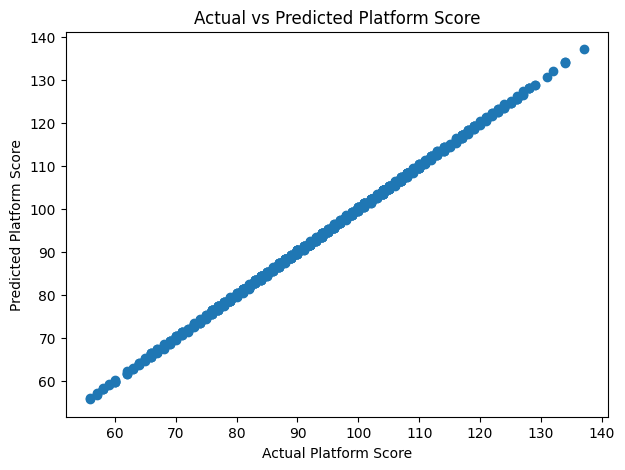

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Platform Score")
plt.ylabel("Predicted Platform Score")
plt.title("Actual vs Predicted Platform Score")

plt.show()

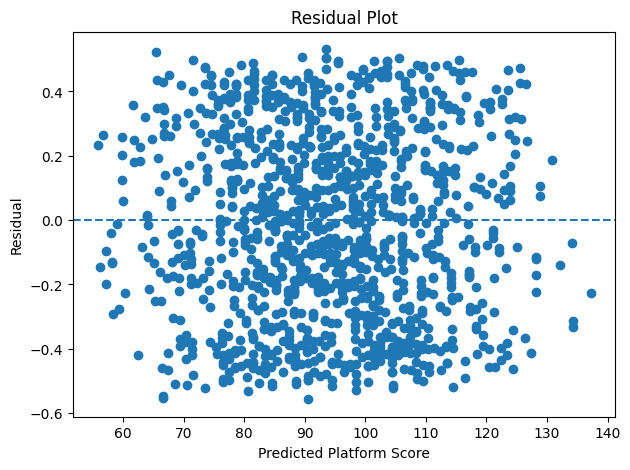

In [98]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Platform Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [99]:
feature_names = (
    linear_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    linear_model
    .named_steps["model"]
    .coef_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(20)

,Feature,Coefficient,Absolute_Coefficient
0,num__Active_Users_M,12.484088,12.484088
4,num__Learning_Paths,5.763684,5.763684
17,cat__Job_Integration_Yes,4.997811,4.997811
16,cat__Job_Integration_No,-4.995656,4.995656
1,num__Avg_Rating,4.359822,4.359822
6,num__Certifications_Offered,2.502710,2.502710
25,cat__Forum_Activity_Level_High,2.009208,2.009208
26,cat__Forum_Activity_Level_Low,-2.007672,2.007672
21,cat__Contest_Frequency_Weekly,1.996731,1.996731
23,cat__Pricing_Model_Freemium,1.664719,1.664719


In [100]:
df.corr(numeric_only=True)["Platform_Score"].sort_values(
    ascending=False
)

Platform_Score            1.000000
Active_Users_M            0.813650
Learning_Paths            0.357289
Avg_Rating                0.265957
Certifications_Offered    0.172001
Founded_Year              0.013267
Problems_Count            0.011242
Mobile_App_Available     -0.010421
Name: Platform_Score, dtype: float64

In [101]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R2 Scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

R2 Scores: [0.99964226 0.99963374 0.99965716 0.99965105 0.99962884]
Mean R2: 0.9996426080932963
Std: 1.0502259021343064e-05


In [102]:
final_model = linear_model

final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Active_Users_M',
                                                   'Avg_Rating',
                                                   'Problems_Count',
                                                   'Founded_Year',
                                                   'Learning_Paths',
                                                   'Mobile_App_Available',
                                                   'Certifications_Offered']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Platform',
                                                   'Problems_Difficulty',
                                                   'Job_Integration',
                                                   'Contest_Frequency',
                                                   'Pricing_Model',
                                                   'Forum_Activity_Level'])])),
                ('model', LinearRegression())])

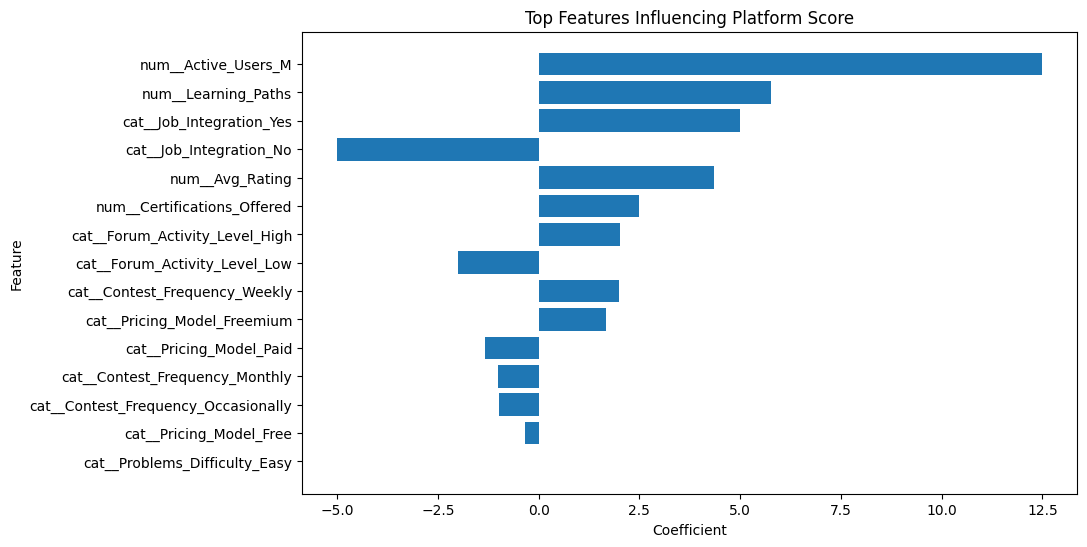

In [103]:
top_features = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Platform Score")
plt.gca().invert_yaxis()

plt.show()

In [105]:
df["Platform_Score"].corr(df["Active_Users_M"])

np.float64(0.8136500116612336)

In [106]:
from sklearn.linear_model import LinearRegression

simple_features = [
    "Active_Users_M",
    "Learning_Paths",
    "Avg_Rating",
    "Certifications_Offered"
]

simple_model = LinearRegression()

simple_model.fit(
    df[simple_features],
    y
)

simple_pred = simple_model.predict(df[simple_features])

print("R2:", r2_score(y, simple_pred))
print("MAE:", mean_absolute_error(y, simple_pred))

R2: 0.9046504815577832
MAE: 3.9912157837203193


In [107]:
final_model = linear_model

final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Active_Users_M',
                                                   'Avg_Rating',
                                                   'Problems_Count',
                                                   'Founded_Year',
                                                   'Learning_Paths',
                                                   'Mobile_App_Available',
                                                   'Certifications_Offered']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Platform',
                                                   'Problems_Difficulty',
                                                   'Job_Integration',
                                                   'Contest_Frequency',
                                                   'Pricing_Model',
                                                   'Forum_Activity_Level'])])),
                ('model', LinearRegression())])

In [108]:
import joblib

joblib.dump(final_model, "platform_score_model.pkl")

['platform_score_model.pkl']